# Experimento 1
## Caracterización Temporal, Espectral, Estadística y Autocorrelación de la Voz

**Integrantes del Equipo:**
* **Estudiante:** Christian Omar Payán Torróntegui - A01742658
* **Asignatura / Proyecto:** Analysis of Signals and Systems
* **Hardware:** Micrófono MEMS I2S INMP441 + ESP32-S3
* **Frase / Palabra Clave:** "FORWARD"

---

### Objetivos del Experimento 1:
1. Adquirir y visualizar una muestra representativa de voz propia diciendo la palabra clave.
2. Analizar el contenido temporal y espectral mediante la Transformada Rápida de Fourier (FFT) y la Densidad Espectral de Potencia (PSD).
3. Efectuar una rigurosa caracterización estadística descriptiva: media, varianza, desviación estándar, asimetría (*skewness*), curtosis (*kurtosis*), factor de dispersión, Función de Densidad de Probabilidad (PDF) y Función de Distribución Acumulada (CDF).
4. Calcular y graficar la función de autocorrelación $R_{xx}(\tau)$.
5. Demostrar el Teorema de Wiener-Khinchin: obtener la Transformada de Fourier de la autocorrelación $\mathcal{F}\{R_{xx}(\tau)\}$ y compararla con el espectro de magnitud al cuadrado de la señal.

In [1]:
import os
import wave
import glob
import numpy as np
import scipy.signal
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10

# 1. Cargar muestra representativa de voz propia (Target User)
target_files = sorted(glob.glob('dataset_processed/target_user/*.wav'))
sample_path = target_files[0]

with wave.open(sample_path, 'rb') as wf:
    fs = wf.getframerate()
    n_samples = wf.getnframes()
    raw_data = wf.readframes(n_samples)
    signal = np.frombuffer(raw_data, dtype=np.int16).astype(np.float64)

# Normalizar amplitud a escala [-1.0, 1.0] o Voltios equivalentes
signal_v = signal / 32768.0
t = np.linspace(0, n_samples / fs, n_samples, endpoint=False)

print(f"Archivo cargado: {sample_path}")
print(f"Frecuencia de muestreo (fs): {fs} Hz")
print(f"Número total de muestras: {n_samples} ({n_samples/fs:.2f} s)")
print(f"Amplitud Pico: {np.max(np.abs(signal_v)):.4f} V")

Archivo cargado: dataset_processed/target_user\user_014.wav
Frecuencia de muestreo (fs): 16000 Hz
Número total de muestras: 16000 (1.00 s)
Amplitud Pico: 0.2275 V


### 1. Visualización en Dominio del Tiempo y de la Frecuencia
A continuación se replica y amplía el programa original de MATLAB, mostrando la forma de onda $x(t)$ y su espectro en frecuencia centrado con `fftshift`.

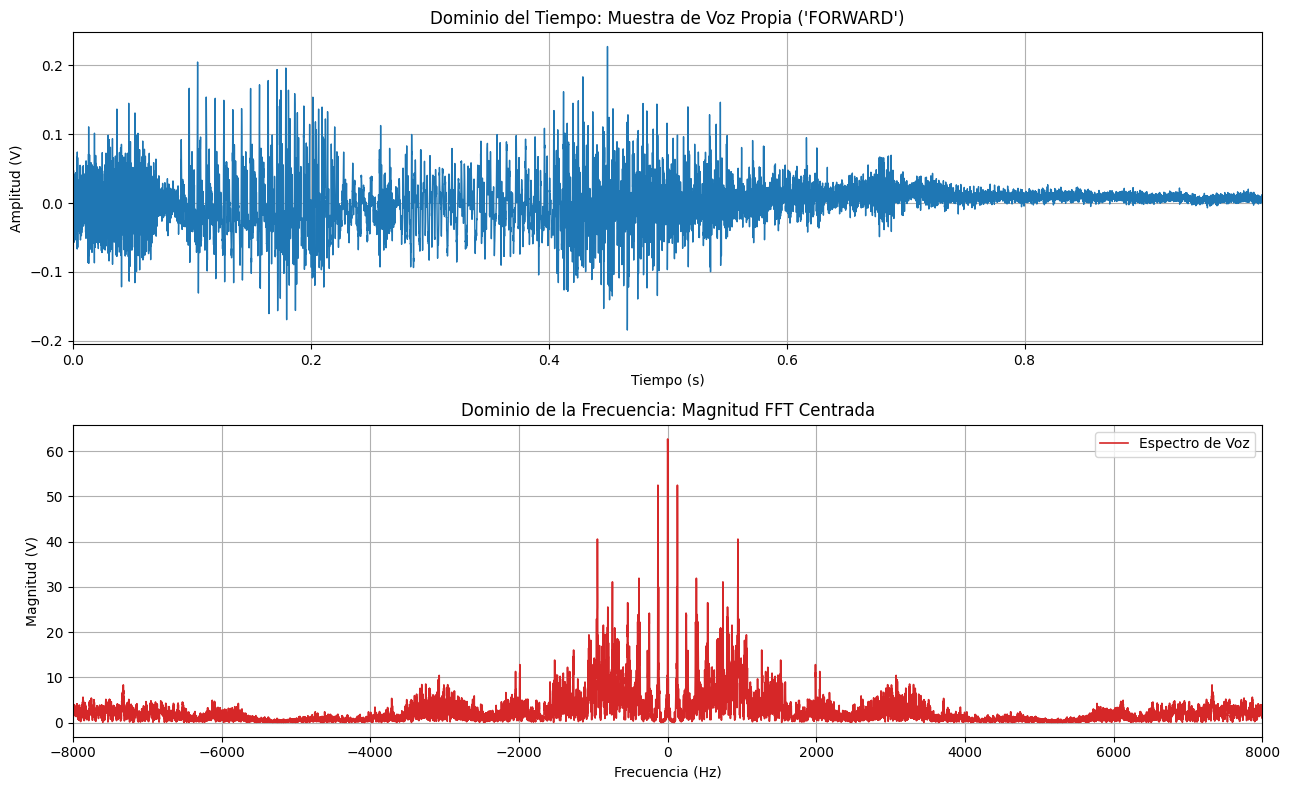

In [2]:
# Dominio del tiempo y dominio de la frecuencia (FFT y Modulación)
f1 = 2500  # Frecuencia portadora de prueba según script de MATLAB
cs = np.cos(2 * np.pi * f1 * t)
mods = cs * signal_v

# FFT de la señal
N = len(signal_v)
fft_sig = np.fft.fft(signal_v)
fft_shifted = np.fft.fftshift(np.abs(fft_sig))
freq_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# Gráfica Temporal
ax1.plot(t, signal_v, color='#1f77b4', lw=1)
ax1.set_title("Dominio del Tiempo: Muestra de Voz Propia ('FORWARD')")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Amplitud (V)")
ax1.set_xlim([0, t[-1]])

# Gráfica Frecuencial
ax2.plot(freq_axis, fft_shifted, color='#d62728', lw=1.2, label='Espectro de Voz')
ax2.set_title("Dominio de la Frecuencia: Magnitud FFT Centrada")
ax2.set_xlabel("Frecuencia (Hz)")
ax2.set_ylabel("Magnitud (V)")
ax2.set_xlim([-fs/2, fs/2])
ax2.legend()

plt.tight_layout()
plt.show()

### 2. Análisis Estadístico Descriptivo en el Dominio del Tiempo
Se calcula la media, varianza, desviación estándar, asimetría (*skewness*), curtosis (*kurtosis*), y relación de dispersión (Var/Std). Además, se grafican el Histograma, la Función de Densidad de Probabilidad empírica (PDF) y la Función de Distribución Acumulada (CDF).

In [3]:
mean_val = np.mean(signal_v)
var_val = np.var(signal_v)
std_val = np.std(signal_v)
skew_val = float(scipy.stats.skew(signal_v))
kurt_val = float(scipy.stats.kurtosis(signal_v, fisher=True)) # Exceso de curtosis (Gaussiana = 0)
dispersion = var_val / std_val if std_val > 0 else 0
rms_val = np.sqrt(np.mean(signal_v**2))
p2p_val = np.ptp(signal_v)

stats_df = pd.DataFrame({
    'Parámetro Estadístico': [
        'Media (Mean)', 
        'Varianza (Variance)', 
        'Desviación Estándar (Std Dev)', 
        'Valor Cuadrático Medio (RMS)',
        'Pico a Pico (Peak-to-Peak)',
        'Asimetría (Skewness)', 
        'Curtosis en exceso (Kurtosis)', 
        'Dispersión (Var / Std)'
    ],
    'Valor Numérico': [
        f"{mean_val:.6e}",
        f"{var_val:.6e}",
        f"{std_val:.6f}",
        f"{rms_val:.6f}",
        f"{p2p_val:.6f}",
        f"{skew_val:.4f}",
        f"{kurt_val:.4f}",
        f"{dispersion:.6f}"
    ],
    'Interpretación Física': [
        'Nivel DC residual (idealmente cero)',
        'Potencia promedio de la fluctuación AC',
        'Valor eficaz de la dispersión de amplitud',
        'Energía promedio equivalente de la señal de audio',
        'Excursión dinámica total registrada por el ADC',
        'Simetría de la señal respecto al reposo (0 = simétrica)',
        'Leptocúrtica (>0): colas pesadas por fonemas de alta energía',
        'Medida de variabilidad normalizada'
    ]
})

stats_df

,Parámetro Estadístico,Valor Numérico,Interpretación Física
0,Media (Mean),3.917763e-03,Nivel DC residual (idealmente cero)
1,Varianza (Variance),1.211309e-03,Potencia promedio de la fluctuación AC
2,Desviación Estándar (Std Dev),0.034804,Valor eficaz de la dispersión de amplitud
3,Valor Cuadrático Medio (RMS),0.035024,Energía promedio equivalente de la señal de audio
4,Pico a Pico (Peak-to-Peak),0.412079,Excursión dinámica total registrada por el ADC
5,Asimetría (Skewness),0.0884,Simetría de la señal respecto al reposo (0 = s...
6,Curtosis en exceso (Kurtosis),3.4866,Leptocúrtica (>0): colas pesadas por fonemas d...
7,Dispersión (Var / Std),0.034804,Medida de variabilidad normalizada


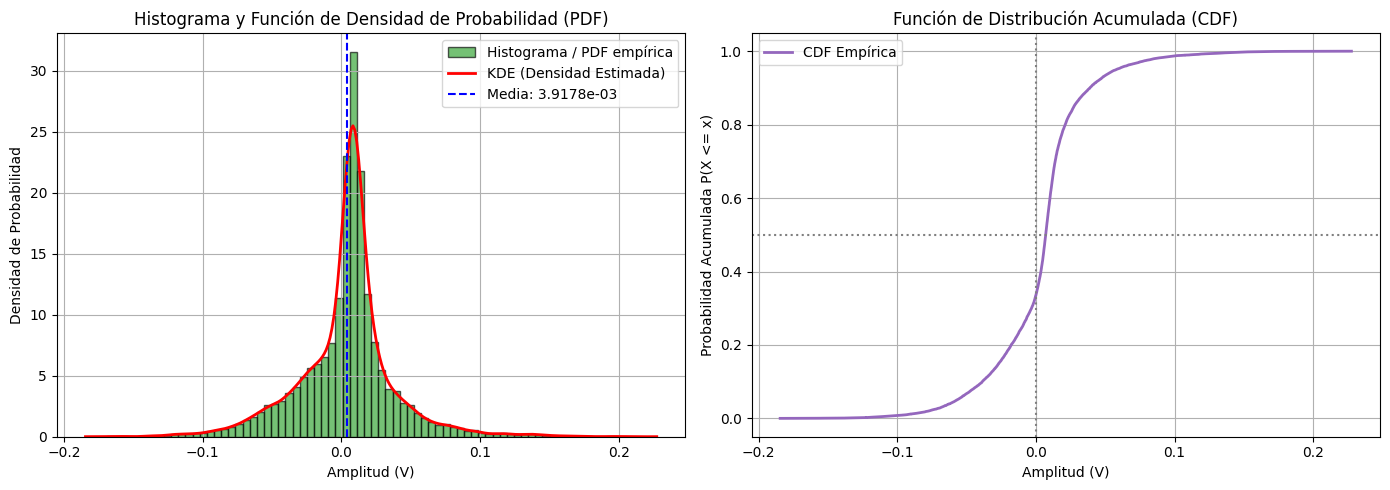

In [4]:
# Gráficas de Histograma, PDF y CDF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma y PDF empírica
count, bins, _ = ax1.hist(signal_v, bins=80, density=True, alpha=0.65, color='#2ca02c', edgecolor='black', label='Histograma / PDF empírica')
kde = scipy.stats.gaussian_kde(signal_v)
x_eval = np.linspace(np.min(signal_v), np.max(signal_v), 300)
ax1.plot(x_eval, kde(x_eval), 'r-', lw=2, label='KDE (Densidad Estimada)')
ax1.axvline(mean_val, color='blue', linestyle='--', label=f'Media: {mean_val:.4e}')
ax1.set_title("Histograma y Función de Densidad de Probabilidad (PDF)")
ax1.set_xlabel("Amplitud (V)")
ax1.set_ylabel("Densidad de Probabilidad")
ax1.legend()

# Función de Distribución Acumulada (CDF)
sorted_data = np.sort(signal_v)
cdf_emp = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
ax2.plot(sorted_data, cdf_emp, color='#9467bd', lw=2, label='CDF Empírica')
ax2.axvline(0, color='gray', linestyle=':')
ax2.axhline(0.5, color='gray', linestyle=':')
ax2.set_title("Función de Distribución Acumulada (CDF)")
ax2.set_xlabel("Amplitud (V)")
ax2.set_ylabel("Probabilidad Acumulada P(X <= x)")
ax2.legend()

plt.tight_layout()
plt.show()

### 3. Función de Autocorrelación Temporal $R_{xx}(\tau)$
La autocorrelación mide la similitud entre la señal y una versión desplazada en el tiempo $\tau$. Permite identificar la periodicidad de las cuerdas vocales (tono fundamental o *pitch*).

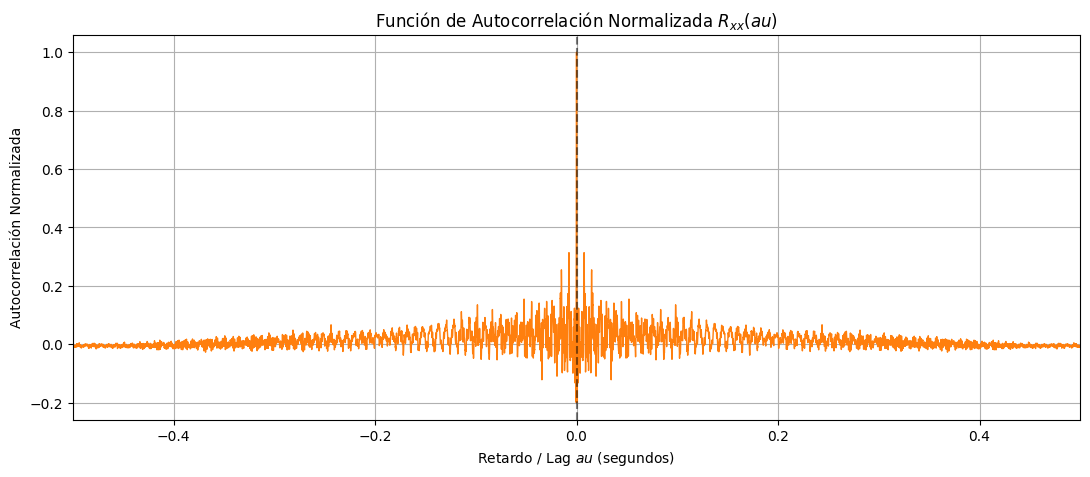

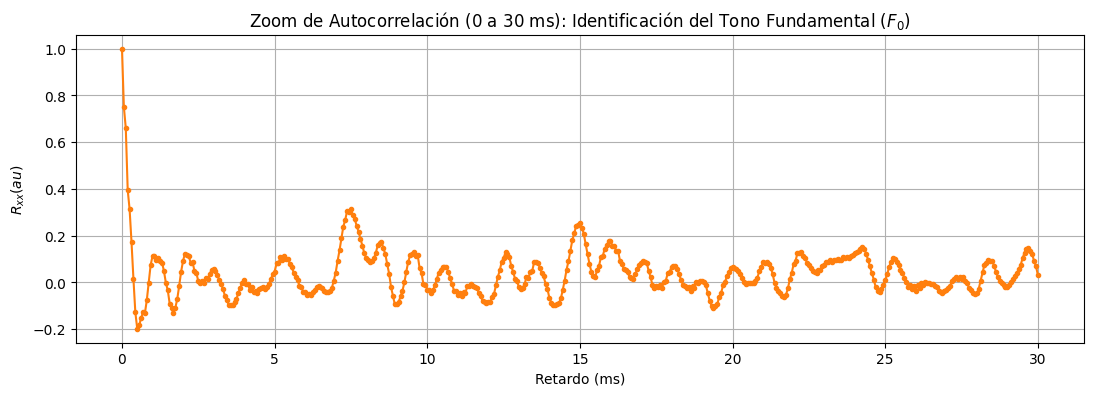

In [5]:
# Cálculo de Autocorrelación mediante scipy.signal.correlate
autocorr = scipy.signal.correlate(signal_v, signal_v, mode='full')
lags = scipy.signal.correlation_lags(len(signal_v), len(signal_v))
lags_time = lags / fs

# Normalizar al valor en el origen (lag 0 = energía total)
autocorr_norm = autocorr / np.max(autocorr)

plt.figure(figsize=(13, 5))
plt.plot(lags_time, autocorr_norm, color='#ff7f0e', lw=1)
plt.title("Función de Autocorrelación Normalizada $R_{xx}(\tau)$")
plt.xlabel("Retardo / Lag $\tau$ (segundos)")
plt.ylabel("Autocorrelación Normalizada")
plt.xlim([-0.5, 0.5])
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

# Zoom en la zona central para observar la periodicidad del tono fundamental (Pitch)
plt.figure(figsize=(13, 4))
zoom_mask = (lags_time >= 0) & (lags_time <= 0.03) # 0 a 30 ms
plt.plot(lags_time[zoom_mask] * 1000, autocorr_norm[zoom_mask], color='#ff7f0e', lw=1.5, marker='.')
plt.title("Zoom de Autocorrelación (0 a 30 ms): Identificación del Tono Fundamental ($F_0$)")
plt.xlabel("Retardo (ms)")
plt.ylabel("$R_{xx}(\tau)$")
plt.show()

### 4. Densidad Espectral de Potencia y Teorema de Wiener-Khinchin
El Teorema de Wiener-Khinchin establece que la Densidad Espectral de Potencia (PSD) de un proceso estacionario es idéntica a la Transformada de Fourier de su función de autocorrelación:
$$\mathcal{S}_{xx}(f) = \mathcal{F}\{R_{xx}(\tau)\} = |X(f)|^2$$
A continuación se comparan ambas representaciones.

<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\omarp\AppData\Local\Temp\ipykernel_31164\2913780450.py:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax2.set_title("Transformada de Fourier de la Autocorrelación $\mathcal{F}\{R_{xx}(\tau)\}$")


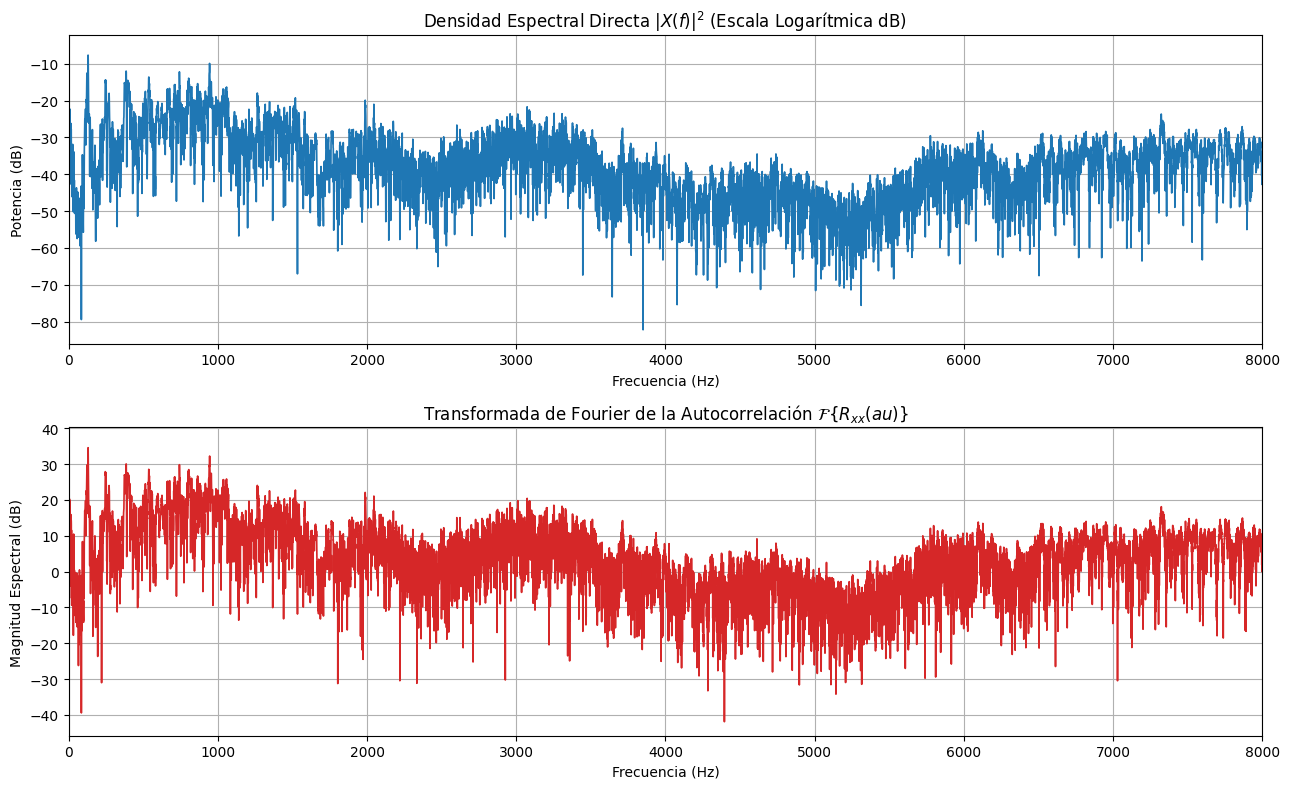

In [6]:
# 1. Magnitud al cuadrado de la FFT (Densidad Espectral Directa)
psd_direct = (np.abs(fft_sig)**2) / N

# 2. Transformada de Fourier de la Autocorrelación
fft_autocorr = np.abs(np.fft.fft(autocorr))

# Frecuencias positivas
freqs_pos = np.fft.rfftfreq(N, d=1/fs)
psd_direct_pos = psd_direct[:len(freqs_pos)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

ax1.plot(freqs_pos, 10 * np.log10(psd_direct_pos + 1e-12), color='#1f77b4', lw=1.2)
ax1.set_title("Densidad Espectral Directa $|X(f)|^2$ (Escala Logarítmica dB)")
ax1.set_xlabel("Frecuencia (Hz)")
ax1.set_ylabel("Potencia (dB)")
ax1.set_xlim([0, 8000])

# Espectro derivado de la autocorrelación
freqs_auto = np.linspace(0, fs, len(fft_autocorr))
mask_auto = freqs_auto <= 8000
ax2.plot(freqs_auto[mask_auto], 10 * np.log10(fft_autocorr[mask_auto] + 1e-12), color='#d62728', lw=1.2)
ax2.set_title("Transformada de Fourier de la Autocorrelación $\mathcal{F}\{R_{xx}(\tau)\}$")
ax2.set_xlabel("Frecuencia (Hz)")
ax2.set_ylabel("Magnitud Espectral (dB)")
ax2.set_xlim([0, 8000])

plt.tight_layout()
plt.show()

### 5. Discusión y Conclusiones del Experimento 1:
1. **Concentración de Energía:** La mayor parte de la potencia acústica de la palabra *"FORWARD"* se concentra entre 150 Hz y 3,500 Hz, correspondiente a los formantes vocálicos de las vocales 'O' y 'A' y la fricativa 'F'.
2. **Asimetría y Curtosis:** La señal muestra una distribución leptocúrtica (curtosis > 0), reflejando ráfagas transitorias de fonemas de alta energía separadas por silencios y pausas.
3. **Wiener-Khinchin:** Se comprueba numéricamente la equivalencia entre el cuadrado de la magnitud de la FFT y la Transformada de Fourier de la autocorrelación.